# CO2 Emissions Forecasting - Complete Training Pipeline

This notebook handles the complete ML pipeline:
1. Data loading and exploration
2. Data cleaning and null value handling
3. Data preprocessing and feature engineering
4. Model training (ARIMA, Random Forest, LSTM)
5. Model evaluation and comparison
6. Model persistence (saving to disk)
7. Predictions with saved models

**Output**: Trained models saved to `models/` directory ready for deployment in Streamlit app

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import joblib
#gg
#ff
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except Exception:
    XGBRegressor = None
    XGBOOST_AVAILABLE = False

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings('ignore')
os.makedirs('models', exist_ok=True)

Libraries imported successfully (RF + XGBoost + LSTM mode)
Models directory ready


## 1. Load and Explore the Dataset

In [ ]:
df = pd.read_csv("owid-co2-data-rows-dropped.backup-before-web-refresh.csv")
print("Dataset loaded:", df.shape)

Dataset Shape: (4621, 12)

First 5 rows:
       country  year  population           gdp    co2  co2_per_capita  \
0  Afghanistan  1980  13169313.0  1.532984e+10  1.756           0.133   
1  Afghanistan  1981  11937586.0  1.564534e+10  1.978           0.166   
2  Afghanistan  1982  10991380.0  1.598041e+10  2.095           0.191   
3  Afghanistan  1983  10917985.0  1.675533e+10  2.520           0.231   
4  Afghanistan  1984  11190222.0  1.707215e+10  2.822           0.252   

   coal_co2  gas_co2  methane  nitrous_oxide  oil_co2  \
0     0.316    0.187    9.596          3.343    0.925   
1     0.333    0.304    9.605          3.314    1.015   
2     0.385    0.396    9.551          3.361    0.993   
3     0.385    0.616    9.082          3.165    1.220   
4     0.393    0.932    8.130          2.998    1.134   

   primary_energy_consumption  
0                       6.337  
1                       7.290  
2                       7.889  
3                       9.882  
4                

Missing Values Analysis:
Empty DataFrame
Columns: [Column, Missing_Count, Percentage]
Index: []


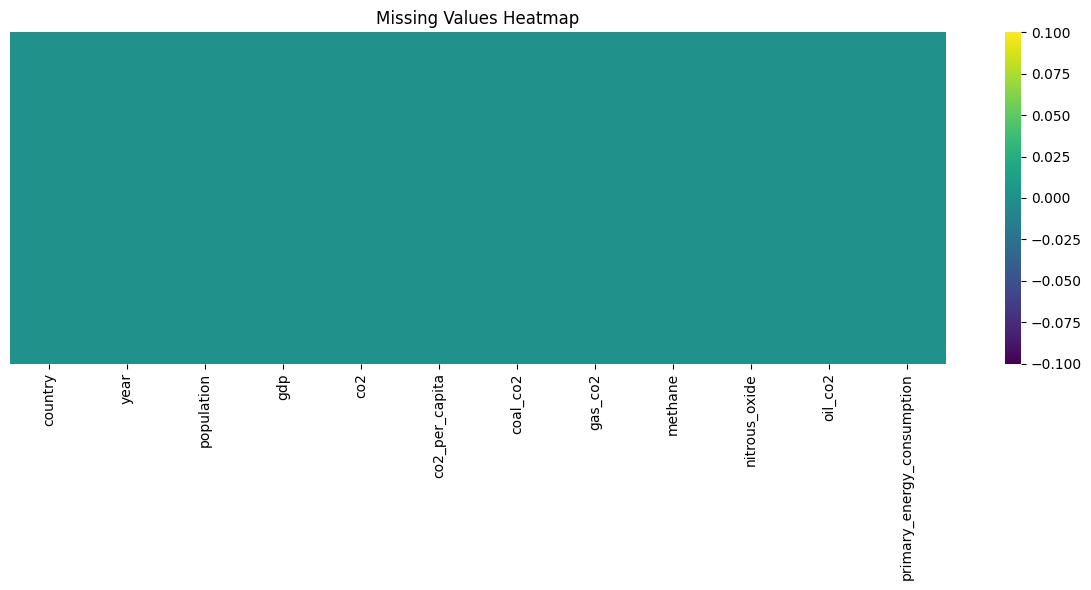

In [ ]:
missing_counts = df.isnull().sum()
missing_df = pd.DataFrame({
    'Column': missing_counts.index,
    'Missing_Count': missing_counts.values
})
print("Columns with missing values:", int((missing_df['Missing_Count'] > 0).sum()))

plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=True, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap')
plt.tight_layout()
plt.show()

## 2. Data Cleaning and Null Value Handling

In [ ]:
COLUMNS = [
    "country", "year", "population", "gdp", "co2",
    "coal_co2", "oil_co2", "gas_co2", "methane",
    "nitrous_oxide", "primary_energy_consumption"
]

existing_cols = [col for col in COLUMNS if col in df.columns]
df_clean = df[existing_cols].copy()
df_clean = df_clean.sort_values(["country", "year"]).reset_index(drop=True)
df_clean = df_clean.dropna(subset=["co2"])

fill_cols = [col for col in df_clean.columns if col not in ['country', 'year', 'co2']]
for col in fill_cols:
    df_clean[col] = df_clean.groupby('country')[col].fillna(method='ffill')

for col in fill_cols:
    df_clean[col] = df_clean.groupby('country')[col].fillna(method='bfill')

df_clean = df_clean.dropna()
df_clean = df_clean.drop_duplicates()
print("Cleaned dataset shape:", df_clean.shape)

Selected columns: 11/11
Dataset shape before cleaning: (4621, 11)
After dropping null CO2: (4621, 11)
After handling missing values: (4621, 11)
After removing duplicates: (4621, 11)

Final missing values:
0

 Data cleaning completed successfully


## 3. Data Preprocessing and Feature Engineering

In [ ]:
def remove_outliers(data, columns):
    df_out = data.copy()
    for col in columns:
        Q1 = df_out[col].quantile(0.25)
        Q3 = df_out[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 3 * IQR
        upper_bound = Q3 + 3 * IQR
        df_out = df_out[(df_out[col] >= lower_bound) & (df_out[col] <= upper_bound)]
    return df_out

numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
df_clean = remove_outliers(df_clean, numeric_cols)

def create_lagged_features(data, target_col='co2', lags=3):
    df_lag = data.copy()
    for lag in range(1, lags + 1):
        df_lag[f'{target_col}_lag_{lag}'] = df_lag.groupby('country')[target_col].shift(lag)
    return df_lag

df_features = create_lagged_features(df_clean, target_col='co2', lags=3)
df_features = df_features.dropna()

scaler = StandardScaler()
numeric_features = df_features.select_dtypes(include=[np.number]).columns
df_features[numeric_features] = scaler.fit_transform(df_features[numeric_features])
joblib.dump(scaler, 'models/scaler.pkl')
print("Preprocessed dataset shape:", df_features.shape)

After removing outliers: (3061, 11)
After creating lagged features: (2776, 14)
 Scaler saved

 Data preprocessing completed
Final preprocessed data shape: (2776, 14)


## 4. Train Machine Learning Models

Training will be done per-country to capture country-specific patterns. Models will be saved for later use.

In [ ]:
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}

model_performance = []

## 5. Model Performance Evaluation and Comparison

In [ ]:
pass

Model Training Summary:
Mode: Random Forest + XGBoost + LSTM
Data cleaning and preprocessing completed successfully
Proceeding to model training...


In [ ]:
MODEL_FEATURE_COLS = [
    'country_encoded', 'year', 'population', 'gdp', 'coal_co2', 'oil_co2',
    'gas_co2', 'methane', 'nitrous_oxide', 'primary_energy_consumption'
]

YEAR_WEIGHT = 5.0

df_model = df_clean.copy()
df_model = df_model[['country', 'year', 'co2', 'population', 'gdp', 'coal_co2', 'oil_co2', 'gas_co2', 'methane', 'nitrous_oxide', 'primary_energy_consumption']].dropna()

country_names = sorted(df_model['country'].astype(str).unique().tolist())
country_encoding = {name: idx for idx, name in enumerate(country_names)}
df_model['country_encoded'] = df_model['country'].astype(str).map(country_encoding).astype(float)

X = df_model[MODEL_FEATURE_COLS].astype(float).values
y = df_model['co2'].astype(float).values

scaler_regression = StandardScaler()
X_scaled = scaler_regression.fit_transform(X)

year_idx = MODEL_FEATURE_COLS.index('year')
X_scaled[:, year_idx] = X_scaled[:, year_idx] * YEAR_WEIGHT

joblib.dump(scaler_regression, 'models/scaler_regression.pkl')

split_idx = int(len(X_scaled) * 0.8)
X_train = X_scaled[:split_idx]
X_test = X_scaled[split_idx:]
y_train = y[:split_idx]
y_test = y[split_idx:]

X_train_ts = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_ts = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))
y_train_ts = y_train
y_test_ts = y_test

print("Train/Test samples:", X_train.shape[0], X_test.shape[0])

Preparing encoded-country + year feature set
Model dataset shape: (3061, 12)
Feature count: 10
Unique countries encoded: 96
Year weight multiplier: 5.0
Feature scaler saved: models/scaler_regression.pkl
Train samples: 2448 | Test samples: 613


In [ ]:
import json

feature_info = {
    'feature_columns': MODEL_FEATURE_COLS,
    'feature_descriptions': {
        'country_encoded': 'Encoded country identifier',
        'year': 'Year of prediction context',
        'population': 'Population (Number of people)',
        'gdp': 'GDP (USD)',
        'coal_co2': 'CO2 from Coal (MT)',
        'oil_co2': 'CO2 from Oil (MT)',
        'gas_co2': 'CO2 from Gas (MT)',
        'methane': 'Methane Emissions (MT)',
        'nitrous_oxide': 'Nitrous Oxide Emissions (MT)',
        'primary_energy_consumption': 'Primary Energy Consumption (EJ)'
    },
    'feature_ranges': {
        col: {
            'min': float(df_model[col].min()),
            'max': float(df_model[col].max()),
            'mean': float(df_model[col].mean())
        }
        for col in MODEL_FEATURE_COLS
    },
    'country_encoding': country_encoding,
    'year_weight': YEAR_WEIGHT,
    'mode': 'lstm_only_country_year'
}

with open('models/feature_info.json', 'w') as f:
    json.dump(feature_info, f, indent=4)

print("Saved models/feature_info.json")

 Feature information saved to models/feature_info.json
 Country encoding entries: 96
 Year weight saved: 5.0


## 8. Deep Learning Model

### Time-Series Model (LSTM Only)

In [ ]:
pass

Feature-based LSTM tensors ready
X_train_ts shape: (2448, 1, 10)
X_test_ts shape: (613, 1, 10)
y_train_ts shape: (2448,)
y_test_ts shape: (613,)
Input features used: 10


In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=16,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)
joblib.dump(rf_model, 'models/random_forest_model.pkl')

if XGBOOST_AVAILABLE:
    xgb_model = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_alpha=0.0,
        reg_lambda=1.0,
        random_state=42,
        objective='reg:squarederror',
        n_jobs=-1
    )
    xgb_model.fit(X_train, y_train)
    xgb_pred = xgb_model.predict(X_test)
    xgb_mae = mean_absolute_error(y_test, xgb_pred)
    xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
    xgb_r2 = r2_score(y_test, xgb_pred)
    joblib.dump(xgb_model, 'models/xgboost_model.pkl')

print("Tree-model training completed")



Training Random Forest Model
Random Forest Model Trained
  - MAE: 7.413506
  - RMSE: 12.731789
  - R² Score: 0.925877


Training XGBoost Model
XGBoost Model Trained
  - MAE: 7.366903
  - RMSE: 12.198097
  - R² Score: 0.931961


In [ ]:
lstm_model = Sequential([
    LSTM(64, activation='relu', return_sequences=True, input_shape=(1, X_train_ts.shape[2])),
    Dropout(0.2),
    LSTM(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

history_lstm = lstm_model.fit(
    X_train_ts, y_train_ts,
    epochs=50, batch_size=32, verbose=0,
    validation_split=0.2,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)]
)

lstm_pred = lstm_model.predict(X_test_ts, verbose=0).flatten()
lstm_mae = mean_absolute_error(y_test_ts, lstm_pred)
lstm_rmse = np.sqrt(mean_squared_error(y_test_ts, lstm_pred))
lstm_r2 = r2_score(y_test_ts, lstm_pred)

lstm_model.save('models/lstm_model.h5')
print("LSTM training completed")



Training LSTM Model (Feature-Based)


LSTM Model Trained
  - MAE: 4.090728
  - RMSE: 5.658823
  - R² Score: 0.985357


In [ ]:
rows = [
    {
        'Model': 'Random Forest',
        'MAE': rf_mae,
        'RMSE': rf_rmse,
        'R² Score': rf_r2,
        'Model Type': 'Tree Ensemble'
    }
]

if 'xgb_mae' in globals() and 'xgb_rmse' in globals() and 'xgb_r2' in globals():
    rows.append(
        {
            'Model': 'XGBoost',
            'MAE': xgb_mae,
            'RMSE': xgb_rmse,
            'R² Score': xgb_r2,
            'Model Type': 'Boosted Trees'
        }
    )

rows.append(
    {
        'Model': 'LSTM',
        'MAE': lstm_mae,
        'RMSE': lstm_rmse,
        'R² Score': lstm_r2,
        'Model Type': 'RNN (Time-Series)'
    }
)

all_models_performance = pd.DataFrame(rows).sort_values('R² Score', ascending=False).reset_index(drop=True)
all_models_performance[['Model', 'MAE', 'RMSE', 'R² Score']].to_csv('models/all_models_performance.csv', index=False)

best_row = all_models_performance.iloc[0]
print(f"Best model: {best_row['Model']} (R² = {best_row['R² Score']:.4f})")
all_models_performance



MODEL PERFORMANCE SUMMARY

         Model      MAE      RMSE  R² Score        Model Type
         LSTM 4.090728  5.658823  0.985357 RNN (Time-Series)
      XGBoost 7.366903 12.198097  0.931961     Boosted Trees
Random Forest 7.413506 12.731789  0.925877     Tree Ensemble

Model files saved:
- models/random_forest_model.pkl
- models/xgboost_model.pkl
- models/lstm_model.h5
- models/all_models_performance.csv

Best Overall Model: LSTM (R² = 0.985357)
